# Diagnostico de modelo de regresion

Este notebook analiza un modelo YA entrenado para responder tres preguntas:
1. Que tan bien predice (metricas globales).
2. Donde falla (segmentos y casos de mayor error).
3. Por que falla (importancia de variables y SHAP opcional).

## 0) Checklist rapido antes de correr

- Tener un modelo guardado en formato `.joblib` o `.pkl`.
- Tener un dataset de evaluacion con la variable target y las features.
- Confirmar nombre de la target y columnas de segmentacion disponibles.
- Si quieres explicabilidad avanzada, instala SHAP en tu entorno.

In [4]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
# =============================
# Configuracion del diagnostico
# =============================

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'Doback-Data').exists():
            return candidate
    return start

REPO_ROOT = find_repo_root(Path.cwd().resolve())

# Rutas configuradas para el modelo encontrado
MODEL_PATH = REPO_ROOT / 'output' / 'models' / 'adaptive_doback_all_rf_best.joblib'
EVAL_DATA_DIR = REPO_ROOT / 'Doback-Data' / 'featured'
EVAL_DATA_GLOB = 'DOBACK*.csv'
TARGET_COL = 'gy'

# Si tu modelo NO guarda feature_names_in_, define una lista explicita aqui
FEATURES_OVERRIDE = None

# Columnas para analizar donde falla el modelo
SEGMENT_COL_CANDIDATES = ['fecha', 'road_name', 'highway']
SPEED_COL = 'speed_kmh'

TOP_K_WORST = 25
MIN_GROUP_SIZE = 80
N_PERMUTATION_REPEATS = 8
N_SHAP_SAMPLES = 2000

print('MODEL_PATH   :', MODEL_PATH)
print('EVAL_DATA_DIR :', EVAL_DATA_DIR)
print('EVAL_DATA_GLOB:', EVAL_DATA_GLOB)
print('TARGET_COL   :', TARGET_COL)

MODEL_PATH   : C:\Users\alexc\Nextcloud\phd-AlexCastilla\code\LiDAR-Stability-algorithm\output\models\adaptive_doback_all_rf_best.joblib
EVAL_DATA_DIR : C:\Users\alexc\Nextcloud\phd-AlexCastilla\code\LiDAR-Stability-algorithm\Doback-Data\featured
EVAL_DATA_GLOB: DOBACK*.csv
TARGET_COL   : gy


In [6]:
def read_table(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'No existe el archivo: {path}')

    suffix = path.suffix.lower()
    if suffix == '.csv':
        return pd.read_csv(path, low_memory=False)
    if suffix in {'.parquet', '.pq'}:
        return pd.read_parquet(path)

    raise ValueError(f'Formato no soportado: {suffix}. Usa .csv o .parquet')


def load_eval_data(path_or_dir: Path, pattern: str = 'DOBACK*.csv') -> pd.DataFrame:
    if path_or_dir.is_file():
        return read_table(path_or_dir)

    if path_or_dir.is_dir():
        files = sorted(path_or_dir.glob(pattern))
        if not files:
            raise FileNotFoundError(f'No se encontraron archivos con patron {pattern} en {path_or_dir}')

        frames = [read_table(f) for f in files]
        df = pd.concat(frames, axis=0, ignore_index=True)
        print(f'Archivos de evaluacion cargados: {len(files)}')
        return df

    raise FileNotFoundError(f'Ruta invalida para evaluacion: {path_or_dir}')


def load_model(path: Path):
    if not path.exists():
        raise FileNotFoundError(f'No existe el modelo: {path}')

    suffix = path.suffix.lower()
    if suffix not in {'.joblib', '.pkl'}:
        raise ValueError('El modelo debe ser .joblib o .pkl')

    loaded = joblib.load(path)

    if isinstance(loaded, dict):
        for key in ['model', 'estimator', 'best_model', 'pipeline']:
            if key in loaded and hasattr(loaded[key], 'predict'):
                return loaded[key]

    if hasattr(loaded, 'predict'):
        return loaded

    raise TypeError('El artefacto cargado no expone metodo predict()')


def infer_feature_columns(model, df: pd.DataFrame, target_col: str, override=None):
    if override is not None:
        return list(override)

    if hasattr(model, 'feature_names_in_'):
        return list(model.feature_names_in_)

    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    if not numeric_cols:
        raise ValueError('No se pudieron inferir features numericas')
    return numeric_cols


model = load_model(Path(MODEL_PATH))
df_eval = load_eval_data(Path(EVAL_DATA_DIR), EVAL_DATA_GLOB)

if TARGET_COL not in df_eval.columns:
    raise ValueError(f'La target {TARGET_COL} no existe en el dataset de evaluacion')

feature_cols = infer_feature_columns(model, df_eval, TARGET_COL, FEATURES_OVERRIDE)
missing_features = [c for c in feature_cols if c not in df_eval.columns]
if missing_features:
    raise ValueError(f'Faltan features en evaluacion: {missing_features[:20]}')

work_cols = feature_cols + [TARGET_COL]
df_work = df_eval[work_cols].dropna().copy()

X_eval = df_work[feature_cols]
y_true = df_work[TARGET_COL]
y_pred = pd.Series(model.predict(X_eval), index=df_work.index, name='y_pred')

print('Filas dataset original :', len(df_eval))
print('Filas usadas en analisis:', len(df_work))
print('Numero de features      :', len(feature_cols))

Archivos de evaluacion cargados: 1185
Filas dataset original : 1609105
Filas usadas en analisis: 1607639
Numero de features      : 8


In [7]:
def safe_mape(y_t: pd.Series, y_p: pd.Series, eps: float = 1e-6) -> float:
    denom = np.maximum(np.abs(y_t), eps)
    return float(np.mean(np.abs(y_t - y_p) / denom) * 100.0)


def regression_metrics(y_t: pd.Series, y_p: pd.Series) -> pd.DataFrame:
    residuals = y_p - y_t
    abs_err = np.abs(residuals)

    metrics = {
        'rmse': float(np.sqrt(mean_squared_error(y_t, y_p))),
        'mae': float(mean_absolute_error(y_t, y_p)),
        'medae': float(median_absolute_error(y_t, y_p)),
        'r2': float(r2_score(y_t, y_p)),
        'mape_percent': safe_mape(y_t, y_p),
        'bias_mean_error': float(np.mean(residuals)),
        'p90_abs_error': float(np.percentile(abs_err, 90)),
        'p95_abs_error': float(np.percentile(abs_err, 95)),
        'max_abs_error': float(np.max(abs_err)),
        'n_samples': int(len(y_t)),
    }
    return pd.DataFrame({'metric': list(metrics.keys()), 'value': list(metrics.values())})


metrics_df = regression_metrics(y_true, y_pred)
display(metrics_df)

,metric,value
0,rmse,2.618335e+03
1,mae,1.379536e+03
2,medae,5.749507e+02
3,r2,-2.123083e-05
4,mape_percent,1.124756e+02
5,bias_mean_error,-1.744634e+01
6,p90_abs_error,3.743377e+03
7,p95_abs_error,5.798459e+03
8,max_abs_error,9.117865e+04
9,n_samples,1.607639e+06


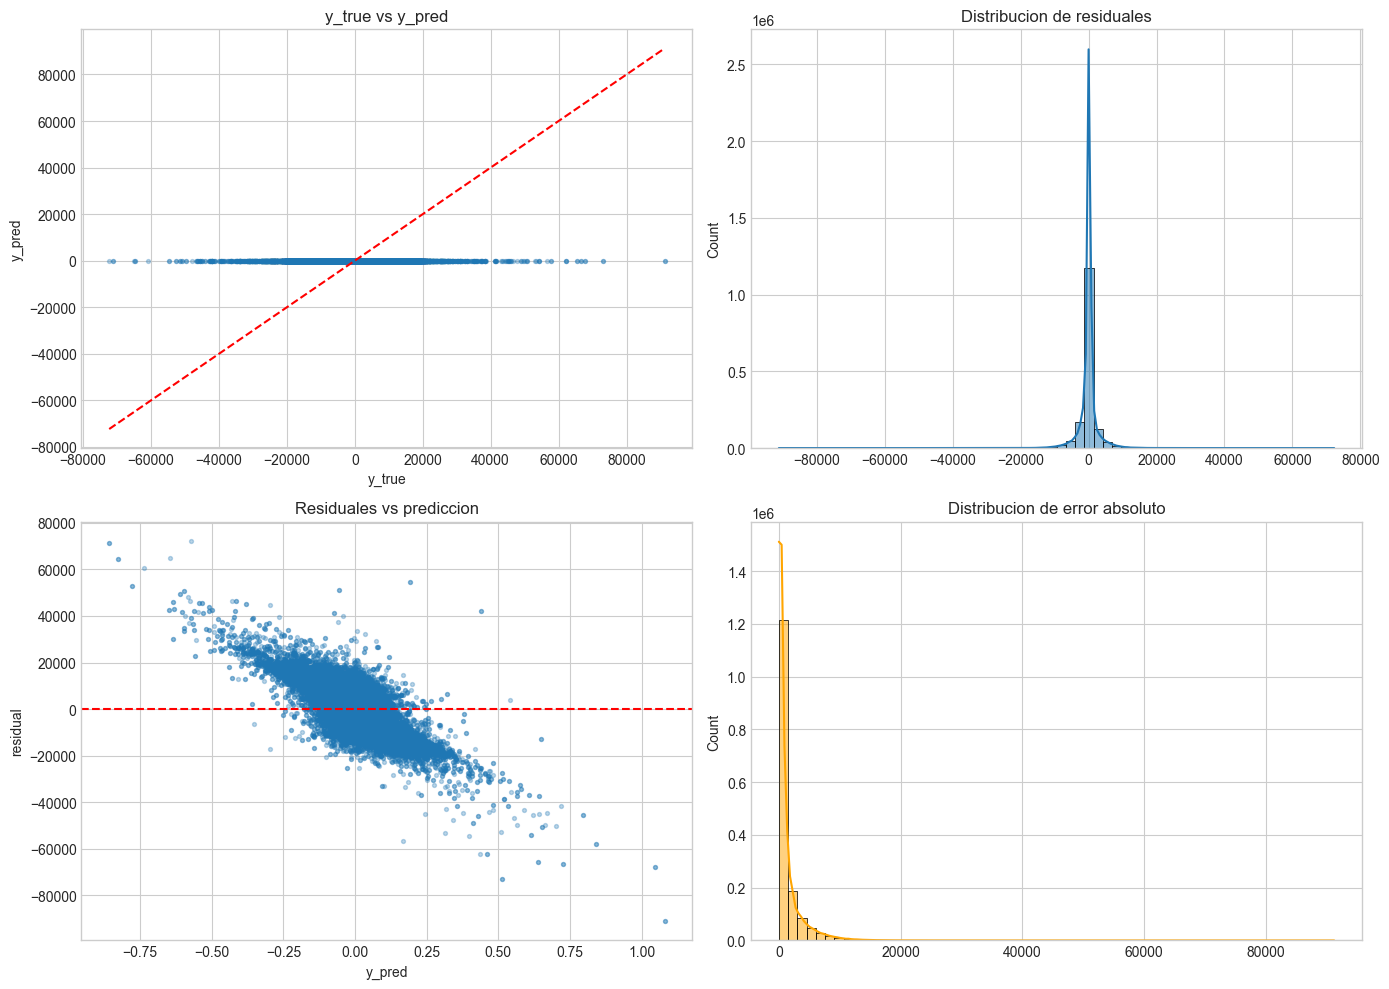

In [8]:
# Graficos base de diagnostico
residuals = y_pred - y_true
abs_error = residuals.abs()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_true, y_pred, s=8, alpha=0.3)
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
axes[0, 0].plot([mn, mx], [mn, mx], color='red', linestyle='--')
axes[0, 0].set_title('y_true vs y_pred')
axes[0, 0].set_xlabel('y_true')
axes[0, 0].set_ylabel('y_pred')

sns.histplot(residuals, bins=60, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribucion de residuales')

axes[1, 0].scatter(y_pred, residuals, s=8, alpha=0.3)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('y_pred')
axes[1, 0].set_ylabel('residual')

sns.histplot(abs_error, bins=60, kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Distribucion de error absoluto')

plt.tight_layout()
plt.show()

In [10]:
# Analisis de fallos por segmentos
df_diag = df_eval.loc[df_work.index].copy()
df_diag['y_true'] = y_true.values
df_diag['y_pred'] = y_pred.values
df_diag['residual'] = df_diag['y_pred'] - df_diag['y_true']
df_diag['abs_error'] = df_diag['residual'].abs()

if SPEED_COL in df_diag.columns:
    df_diag['speed_bin'] = pd.cut(
        df_diag[SPEED_COL],
        bins=[-0.1, 20, 40, 60, 90, np.inf],
        labels=['0-20', '20-40', '40-60', '60-90', '90+']
    )


def group_error_report(df: pd.DataFrame, group_col: str, min_n: int = 50) -> pd.DataFrame:
    if group_col not in df.columns:
        return pd.DataFrame()

    rep = (
        df.groupby(group_col, dropna=False)
        .agg(
            n=('abs_error', 'size'),
            mae=('abs_error', 'mean'),
            rmse=('residual', lambda s: float(np.sqrt(np.mean(np.square(s))))),
            bias=('residual', 'mean'),
            p95_abs=('abs_error', lambda s: float(np.percentile(s, 95))),
        )
        .reset_index()
    )

    rep = rep[rep['n'] >= min_n].sort_values(['mae', 'rmse'], ascending=False)
    return rep


segment_reports = {}
for col in SEGMENT_COL_CANDIDATES + (['speed_bin'] if 'speed_bin' in df_diag.columns else []):
    report = group_error_report(df_diag, col, min_n=MIN_GROUP_SIZE)
    if not report.empty:
        segment_reports[col] = report
        print(f'Top segmentos problematicos para: {col}')
        display(report.head(12))

if not segment_reports:
    print('No se pudieron construir reportes por segmentos con las columnas candidatas.')

Top segmentos problematicos para: fecha


,fecha,n,mae,rmse,bias,p95_abs
6,04/11/2025,10945,3555.051407,5567.202287,-119.656002,12924.252500
16,09/11/2025,38496,2764.412567,4417.950344,-604.461458,9898.538789
35,19/10/2025,7813,2286.534422,3023.389547,-1262.232671,6068.034852
45,29/09/2025,46266,2276.757526,3806.109422,81.994106,8282.458296
23,13/10/2025,4716,2266.275857,3628.902548,-52.970857,8139.766562
31,17/10/2025,10384,2176.896179,2575.735944,-1418.627978,4240.296286
14,08/11/2025,36624,2135.302799,3456.220720,591.474737,7318.903326
17,10/10/2025,47423,2126.746901,3929.239880,150.995092,8251.333835
43,27/10/2025,51163,2096.329692,3673.017194,59.984914,8729.661230
33,18/10/2025,239,1945.649635,2660.503291,52.863668,5422.487449


Top segmentos problematicos para: road_name


,road_name,n,mae,rmse,bias,p95_abs
87,Calle Jarama,1419,5894.125873,7678.373054,979.213101,15625.363623
236,"['Calle Juan XXIII', 'Calle Juan Zapata', 'Cal...",108,5443.998494,6971.373635,796.013430,14117.308935
90,Calle Maestro Guerrero,194,5121.738710,6242.419181,3729.752036,11005.931759
175,Calle de la Marquesa Viuda de Aldama,273,5097.997565,8031.632782,312.082461,15937.333648
154,Calle de Mariano Sebastián Izuel,690,4776.386394,6890.018092,827.809596,14185.080403
130,Calle de Anabel Segura,444,4426.494188,6854.206185,761.946122,14844.008537
207,Manuel de Falla,500,4284.557181,5657.356220,-1484.307715,11349.539786
153,Calle de Manuel de Falla,4404,4155.099356,5644.491888,-1398.644057,11537.642916
40,Avenida del Cerro del Águila,277,4136.673357,4823.714690,-2884.671410,8631.581613
105,Calle Quejigo,262,3949.738506,5210.514513,238.287094,10809.247098


Top segmentos problematicos para: highway


,highway,n,mae,rmse,bias,p95_abs
15,trunk_link,858,3779.847333,5124.002936,-1884.631770,10803.566666
6,"['tertiary', 'residential']",479,3159.974219,6241.357791,74.501529,12025.103428
16,unclassified,23351,2746.593108,3877.785725,-618.830549,8416.623196
14,trunk,23716,2141.073544,3349.559056,-312.860955,7510.295455
4,"['secondary', 'primary']",1509,2117.430018,4032.286901,-156.181789,9761.308552
12,secondary,57664,2014.851355,3479.265107,-173.983824,7653.738353
9,motorway_link,17004,1874.401294,3182.387983,50.753731,7253.394202
10,primary,30617,1864.904403,3467.214374,86.624125,7693.570537
7,living_street,40929,1850.796051,3473.837953,263.467958,7392.677931
13,tertiary,272223,1561.285377,2958.854133,158.569070,6633.610179


Top segmentos problematicos para: speed_bin


,speed_bin,n,mae,rmse,bias,p95_abs
3,60-90,114008,1715.890783,3077.765051,-110.311115,6922.629500
1,20-40,185763,1634.871619,3002.262162,-74.346208,6620.172898
2,40-60,80032,1612.850729,2992.657123,-126.819660,6618.495737
0,0-20,1198105,1296.317422,2482.878821,7.047716,5526.300212
4,90+,29731,1219.879768,2351.494904,1.528229,4997.014455


In [11]:
# Casos con mayor error absoluto (inspeccion directa)
worst_cases = df_diag.sort_values('abs_error', ascending=False).head(TOP_K_WORST)
cols_for_review = [c for c in [TARGET_COL, 'y_pred', 'abs_error', SPEED_COL, 'phi_lidar', 'tri', 'ruggedness', 'road_name', 'fecha'] if c in worst_cases.columns]
display(worst_cases[cols_for_review])

,gy,y_pred,abs_error,speed_kmh,phi_lidar,tri,ruggedness,road_name,fecha
777002,91179.73,1.079826,91178.650174,39.96,0.000582,0.117197,0.003836,NaN,08/11/2025
769106,91179.73,1.079826,91178.650174,39.96,0.000582,0.117197,0.003836,NaN,08/11/2025
240145,73176.42,0.511726,73175.908274,0.20,-0.000590,0.388947,0.010904,NaN,10/10/2025
217023,73176.42,0.511726,73175.908274,0.20,-0.000590,0.388947,0.010904,NaN,10/10/2025
98665,-72282.09,-0.573547,72281.516453,0.16,-0.001855,0.277149,0.006748,Avenida de Fernando Alonso,07/10/2025
217066,-71185.45,-0.857859,71184.592141,0.19,0.001116,0.393455,0.010070,NaN,10/10/2025
240188,-71185.45,-0.857859,71184.592141,0.19,0.001116,0.393455,0.010070,NaN,10/10/2025
777008,67852.23,1.045173,67851.184827,46.98,-0.000325,0.128438,0.003989,NaN,08/11/2025
769112,67852.23,1.045173,67851.184827,46.98,-0.000325,0.128438,0.003989,NaN,08/11/2025
186786,66656.54,0.725427,66655.814573,0.16,-0.001531,0.569003,0.018306,NaN,09/10/2025


In [ ]:
# Importancia global: MDI del modelo y permutation importance (version optimizada)
import time

mdi_df = pd.DataFrame()
if hasattr(model, 'feature_importances_'):
    mdi_df = pd.DataFrame({
        'feature': feature_cols,
        'importance_mdi': model.feature_importances_,
    }).sort_values('importance_mdi', ascending=False)
    print('Top importancia MDI')
    display(mdi_df.head(20))

# Parametros para acelerar permutation importance con datasets grandes
PERM_MAX_SAMPLES = 120_000
PERM_MAX_FEATURES = 20

perm_repeats = N_PERMUTATION_REPEATS if len(X_eval) <= 300_000 else max(3, min(5, N_PERMUTATION_REPEATS))
perm_n = min(PERM_MAX_SAMPLES, len(X_eval))

if perm_n < len(X_eval):
    sample_idx = X_eval.sample(n=perm_n, random_state=42).index
    X_perm = X_eval.loc[sample_idx].copy()
    y_perm = y_true.loc[sample_idx].copy()
    print(f'Permutation sobre muestra: {perm_n:,} / {len(X_eval):,} filas')
else:
    X_perm = X_eval.copy()
    y_perm = y_true.copy()
    print(f'Permutation sobre dataset completo: {len(X_eval):,} filas')

if not mdi_df.empty and len(feature_cols) > PERM_MAX_FEATURES:
    perm_features = mdi_df.head(PERM_MAX_FEATURES)['feature'].tolist()
    X_perm = X_perm[perm_features]
    print(f'Features para permutation: top {len(perm_features)} segun MDI')
else:
    perm_features = list(X_perm.columns)
    print(f'Features para permutation: {len(perm_features)}')

t0 = time.perf_counter()
perm = permutation_importance(
    model,
    X_perm,
    y_perm,
    n_repeats=perm_repeats,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
)
dt = time.perf_counter() - t0

perm_df = pd.DataFrame({
    'feature': perm_features,
    'importance_perm_mean': perm.importances_mean,
    'importance_perm_std': perm.importances_std,
}).sort_values('importance_perm_mean', ascending=False)

print(f'Permutation finalizado en {dt:.1f}s con {perm_repeats} repeticiones')
print('Top permutation importance')
display(perm_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=perm_df.head(15), x='importance_perm_mean', y='feature', palette='viridis')
plt.title('Top 15 - Permutation importance (optimizado)')
plt.xlabel('Mean importance drop (MAE)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Top importancia MDI


,feature,importance_mdi
1,gz,0.241697
4,yaw,0.191057
0,gx,0.141595
2,roll,0.138048
3,pitch,0.134050
5,phi_lidar,0.057166
6,ruggedness,0.049398
7,z_std,0.046989


Permutation sobre muestra: 120,000 / 1,607,639 filas
Features para permutation: 8


In [ ]:
# SHAP opcional (global y local)
shap_available = True
try:
    import shap
except Exception as ex:
    shap_available = False
    print('SHAP no disponible. Instala con: pip install shap')
    print('Detalle:', ex)

if shap_available:
    sample_n = min(N_SHAP_SAMPLES, len(X_eval))
    X_shap = X_eval.sample(n=sample_n, random_state=42) if len(X_eval) > sample_n else X_eval.copy()

    # Para modelos de arboles, TreeExplainer suele ser la opcion mas estable
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)
    except Exception:
        explainer = shap.Explainer(model.predict, X_shap)
        shap_values = explainer(X_shap)

    print('Resumen SHAP global')
    shap.summary_plot(shap_values, X_shap, show=True)

    top_features = perm_df.head(3)['feature'].tolist() if 'perm_df' in globals() else feature_cols[:3]
    for feat in top_features:
        if feat in X_shap.columns:
            shap.dependence_plot(feat, shap_values, X_shap, show=True)

    # Explicacion local sobre casos de mayor error
    print('Explicacion local SHAP en casos con mayor error')
    worst_idx = df_diag.sort_values('abs_error', ascending=False).head(3).index
    X_local = X_eval.loc[worst_idx]

    try:
        local_vals = explainer.shap_values(X_local) if hasattr(explainer, 'shap_values') else explainer(X_local)
        shap.summary_plot(local_vals, X_local, show=True)
    except Exception as ex:
        print('No se pudo generar SHAP local:', ex)

## Plantilla de conclusiones accionables

Usa esta estructura al cerrar el analisis:

1. **Que tan bien funciona**: resume RMSE, MAE, R2, sesgo, p95 error.
2. **Donde falla**: lista top segmentos por MAE/RMSE y top casos de error.
3. **Por que falla**: cruza SHAP/permutation con segmentos para identificar causas probables.
4. **Que cambiar primero**: prioriza acciones en datos, features y modelo.
5. **Como validar la mejora**: define test A/B o comparacion antes/despues con mismas metricas.

In [ ]:
# Validacion explicita del artefacto guardado por adaptive_hyperparam_search
artifact = joblib.load(Path(MODEL_PATH))
print('Tipo artefacto:', type(artifact).__name__)
if isinstance(artifact, dict):
    print('Claves:', sorted(artifact.keys()))
    model_from_artifact = artifact.get('model', None)
    print('Tipo artifact["model"]:', type(model_from_artifact).__name__ if model_from_artifact is not None else None)
    print('Tiene predict():', hasattr(model_from_artifact, 'predict') if model_from_artifact is not None else False)
    if 'feature_columns' in artifact:
        print('N feature_columns:', len(artifact['feature_columns']))
else:
    print('Tiene predict():', hasattr(artifact, 'predict'))
    print('Nota: artefacto no dict, se usa directo como estimador')